# GRAPH-01 — Résultats en graphiques

Restitution visuelle des deux pipelines et de leur cohérence. Lecture seule des
fichiers de phase, aucune écriture dans la chaîne.

Trois séries de figures : la répartition des statuts par pipeline, le détail par
phase, et la synthèse de cohérence. Les images sont écrites dans
`results/graphiques/`.

## Imports et palette

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../..'))

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from pathlib import Path

from config.settings import RESULTS_DIR

DOSSIER_FIGURES = RESULTS_DIR / "graphiques"
DOSSIER_FIGURES.mkdir(parents=True, exist_ok=True)

plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['font.size']   = 11
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

# Palette ANS (bleu marine + bleu ciel + rose framboise)
COULEURS = {
    'VALIDE_FORT':    '#1F3864',
    'VALIDE':         '#2E75B6',
    'DOUTEUX':        '#D4A017',
    'REJETE':         '#C00060',
    'SANS_SIREN':     '#A6A6A6',
    'SANS_SIRET':     '#A6A6A6',
    'SIREN_INCONNU':  '#808080',
    'SIRET_INCONNU':  '#808080',
    'SANS_CANDIDAT':  '#404040',
    'NON_FIABLE_APE': '#8E44AD',
}

# Ordre d'affichage logique (du plus positif au plus indéterminé)
ORDRE_STATUTS_SN = ['VALIDE_FORT', 'VALIDE', 'DOUTEUX', 'REJETE',
                    'SANS_SIREN', 'SIREN_INCONNU', 'SANS_CANDIDAT']
ORDRE_STATUTS_ST = ['VALIDE_FORT', 'VALIDE', 'DOUTEUX', 'REJETE',
                    'SANS_SIRET', 'SIRET_INCONNU', 'SANS_CANDIDAT', 'NON_FIABLE_APE']

# Hiérarchie pour la déduplication : score = meilleur verdict obtenu
PRIORITE_STATUT = {
    'VALIDE_FORT':   1,
    'VALIDE':        2,
    'DOUTEUX':       3,
    'NON_FIABLE_APE':4,
    'REJETE':        5,
    'SANS_CANDIDAT': 6,
    'SANS_SIRET':    7,
    'SANS_SIREN':    7,
    'SIRET_INCONNU': 8,
    'SIREN_INCONNU': 8,
}

## Chargement des données (sirenisation + siretisation)

In [2]:
from src.comparaison import (
    charger_sirenisation, charger_siretisation, construire_vue_coherence,
)
from config.settings import (
    SN_PHASE1, SN_PHASE2, SN_PHASE3,
    ST_PHASE1, ST_PHASE2, ST_PHASE3,
)

ID_PM  = 'NB_PmSmsseId'
ID_EGE = 'NB_EgeId'

df_sn = charger_sirenisation(SN_PHASE1, SN_PHASE2, SN_PHASE3)
df_st = charger_siretisation(ST_PHASE1, ST_PHASE2, ST_PHASE3)

print(f'Sirenisation (brut, toutes phases) : {len(df_sn):,} lignes')
print(f'Siretisation (brut, toutes phases) : {len(df_st):,} lignes')

Sirenisation (brut, toutes phases) : 77,077 lignes
Siretisation (brut, toutes phases) : 160,686 lignes


## Déduplication : 1 ligne par entité = verdict final

Pour avoir une synthèse cohérente avec la base d'entités traitées (sans
doublons), on garde pour chaque entité **uniquement son meilleur statut atteint
à travers les 3 phases**.

Règle : VALIDE_FORT > VALIDE > DOUTEUX > REJETE > SANS_CANDIDAT >
SANS_SIRET/SIREN > SIRET/SIREN_INCONNU

In [3]:
def statut_final_par_entite(df, id_col):
    """
    Pour chaque entité (PM ou EGE), garde son verdict final :
      - si validée en P1 → P1
      - sinon si validée en P2 → P2
      - sinon → sa trace en P3 (phase de clôture)

    Logique : on parcourt P1 → P2 → P3 ; on retient la première phase où
    l'entité est validée. Si jamais validée, on retient sa trace de la
    dernière phase où elle apparaît (la P3 normalement).
    """
    VALIDES = {'VALIDE_FORT', 'VALIDE'}
    df = df.copy()

    p1_valides = df[(df['phase'] == 1) & (df['statut'].isin(VALIDES))]

    ids_v1 = set(p1_valides[id_col].astype(str))
    p2_valides = df[
        (df['phase'] == 2) &
        (df['statut'].isin(VALIDES)) &
        (~df[id_col].astype(str).isin(ids_v1))
    ]

    ids_resolus = ids_v1 | set(p2_valides[id_col].astype(str))
    df_reste = df[~df[id_col].astype(str).isin(ids_resolus)].copy()

    df_reste = df_reste.sort_values('phase', ascending=False) \
                       .drop_duplicates(id_col, keep='first')

    return pd.concat([p1_valides, p2_valides, df_reste], ignore_index=True)


df_sn_synth = statut_final_par_entite(df_sn, ID_PM)
df_st_synth = statut_final_par_entite(df_st, ID_EGE)

print(f'Sirenisation : {len(df_sn_synth):,} PM uniques (verdict final)')
print(df_sn_synth['statut'].value_counts().to_string())
print()
print(f'Siretisation : {len(df_st_synth):,} EGE uniques (verdict final)')
print(df_st_synth['statut'].value_counts().to_string())

Sirenisation : 56,193 PM uniques (verdict final)
statut
VALIDE         27900
VALIDE_FORT    25929
DOUTEUX         2334
REJETE            30

Siretisation : 104,649 EGE uniques (verdict final)
statut
VALIDE            64779
VALIDE_FORT       29676
DOUTEUX            8007
NON_FIABLE_APE     1578
REJETE              608
SANS_CANDIDAT         1


## Fonction utilitaire : camembert élégant sans chevauchement

In [4]:
def camembert_elegant(compteurs, palette, titre, fichier, libelle_unite='entités'):
    """
    Camembert classique avec :
      - pourcentage écrit sur la tranche (si >= 3 %)
      - légende externe (statut · count · %)
      - aucun chevauchement
    """
    total = compteurs.sum()
    couleurs = [palette.get(s, '#666666') for s in compteurs.index]

    fig, ax = plt.subplots(figsize=(11, 7), subplot_kw=dict(aspect='equal'))

    def fmt_pct(p):
        return f'{p:.1f} %' if p >= 3 else ''

    wedges, texts, autotexts = ax.pie(
        compteurs.values,
        colors=couleurs,
        startangle=90,
        counterclock=False,
        autopct=fmt_pct,
        pctdistance=0.72,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2.5},
        textprops={'fontsize': 11, 'color': 'white', 'fontweight': 'bold'},
    )

    labels_legende = [
        f'{statut}   ·   {n:,}'.replace(',', ' ') + f'   ({n/total*100:.1f} %)'
        for statut, n in zip(compteurs.index, compteurs.values)
    ]
    ax.legend(
        wedges, labels_legende,
        title=f'Total : {total:,} {libelle_unite}'.replace(',', ' '),
        title_fontsize=12,
        loc='center left',
        bbox_to_anchor=(1.05, 0.5),
        frameon=False,
        fontsize=10.5,
        labelspacing=0.9,
    )

    ax.set_title(titre, fontsize=15, fontweight='bold', color='#1F3864', pad=20)
    plt.tight_layout()
    plt.savefig(fichier, dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()

## Camembert sirenisation (synthèse finale)

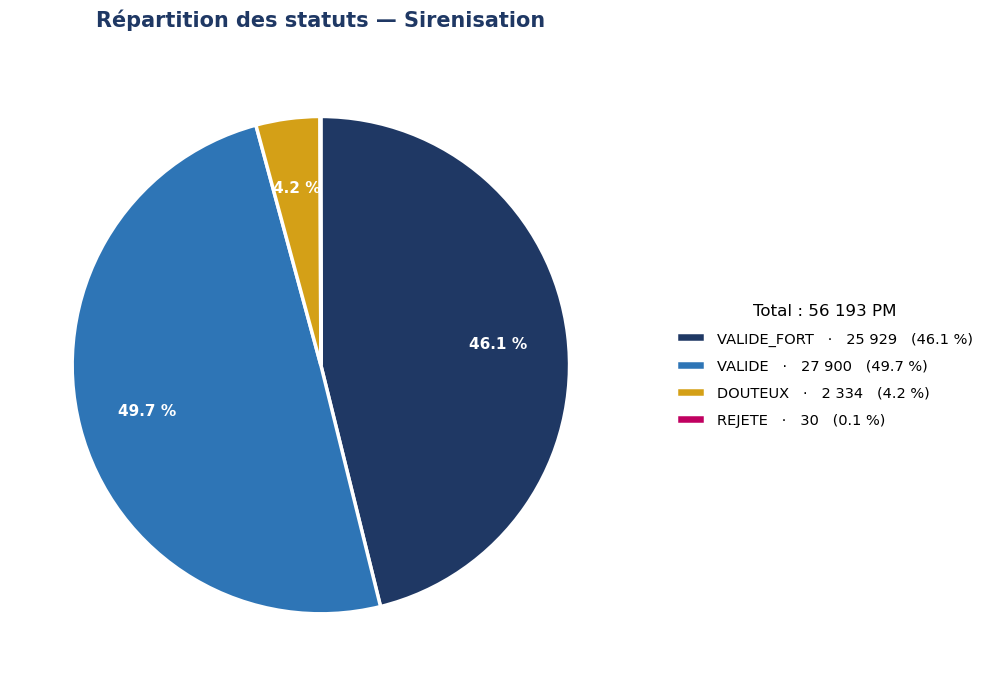

In [5]:
compteurs_sn = df_sn_synth['statut'].value_counts()
compteurs_sn = compteurs_sn.reindex(
    [s for s in ORDRE_STATUTS_SN if s in compteurs_sn.index]
)

camembert_elegant(
    compteurs_sn, COULEURS,
    'Répartition des statuts — Sirenisation',
    DOSSIER_FIGURES / 'sirenisation_pie.png',
    libelle_unite='PM',
)

## Camembert siretisation (synthèse finale)

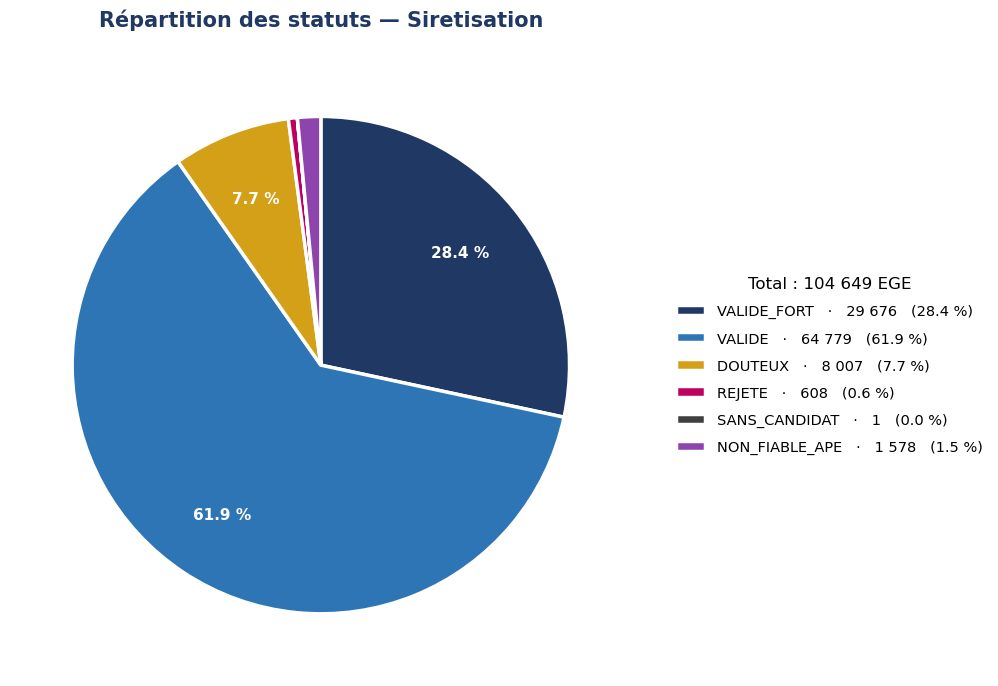

In [6]:
compteurs_st = df_st_synth['statut'].value_counts()
compteurs_st = compteurs_st.reindex(
    [s for s in ORDRE_STATUTS_ST if s in compteurs_st.index]
)

camembert_elegant(
    compteurs_st, COULEURS,
    'Répartition des statuts — Siretisation',
    DOSSIER_FIGURES / 'siretisation_pie.png',
    libelle_unite='EGE',
)

## Histogramme empilé par phase

Détaille pour chaque phase le nombre d'entités par statut **dans la synthèse
finale** (pas les candidats intermédiaires).

In [7]:
def histo_empile_par_phase(df_synth, ordre_statuts, palette, titre, fichier):
    phases = [1, 2, 3]
    table = pd.crosstab(df_synth['phase'], df_synth['statut']).reindex(phases, fill_value=0)
    statuts_presents = [s for s in ordre_statuts if s in table.columns]
    table = table[statuts_presents]

    fig, ax = plt.subplots(figsize=(11, 6.5))

    bas = np.zeros(len(phases))
    for statut in statuts_presents:
        valeurs = table[statut].values
        couleur = palette.get(statut, '#666666')
        ax.bar(phases, valeurs, bottom=bas, label=statut,
               color=couleur, edgecolor='white', linewidth=1.5, width=0.55)

        for i, (v, b) in enumerate(zip(valeurs, bas)):
            total_phase = table.iloc[i].sum()
            if total_phase > 0 and v > total_phase * 0.03:
                ax.text(phases[i], b + v/2, f'{v:,}'.replace(',', ' '),
                        ha='center', va='center', fontsize=9.5,
                        color='white', fontweight='bold')
        bas += valeurs

    for i, p in enumerate(phases):
        total = table.iloc[i].sum()
        if total > 0:
            ax.text(p, total + total * 0.02, f'{total:,}'.replace(',', ' '),
                    ha='center', va='bottom', fontsize=11, fontweight='bold',
                    color='#1F3864')

    ax.set_xticks(phases)
    ax.set_xticklabels([f'Phase {p}' for p in phases], fontsize=12)
    ax.set_ylabel("Nombre d'entités", fontsize=11)
    ax.set_title(titre, fontsize=15, fontweight='bold', color='#1F3864', pad=20)
    ax.grid(axis='y', linestyle='--', alpha=0.3, zorder=0)
    ax.set_axisbelow(True)

    total_max = table.sum(axis=1).max()
    if total_max > 0:
        ax.set_ylim(0, total_max * 1.12)

    ax.legend(
        title='Statuts', title_fontsize=12,
        loc='center left', bbox_to_anchor=(1.02, 0.5),
        frameon=False, fontsize=10.5, labelspacing=0.7,
    )
    plt.tight_layout()
    plt.savefig(fichier, dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()

## Histogramme empilé par phase — sirenisation

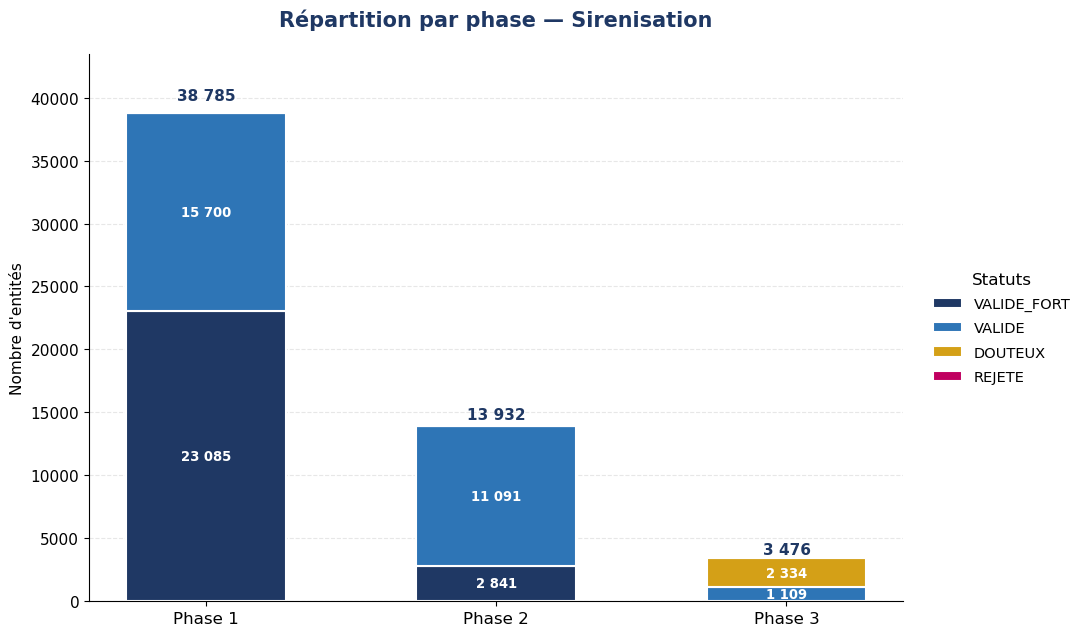

In [8]:
histo_empile_par_phase(
    df_sn_synth, ORDRE_STATUTS_SN, COULEURS,
    'Répartition par phase — Sirenisation',
    DOSSIER_FIGURES / 'sn_par_phase.png',
)

## Histogramme empilé par phase — siretisation

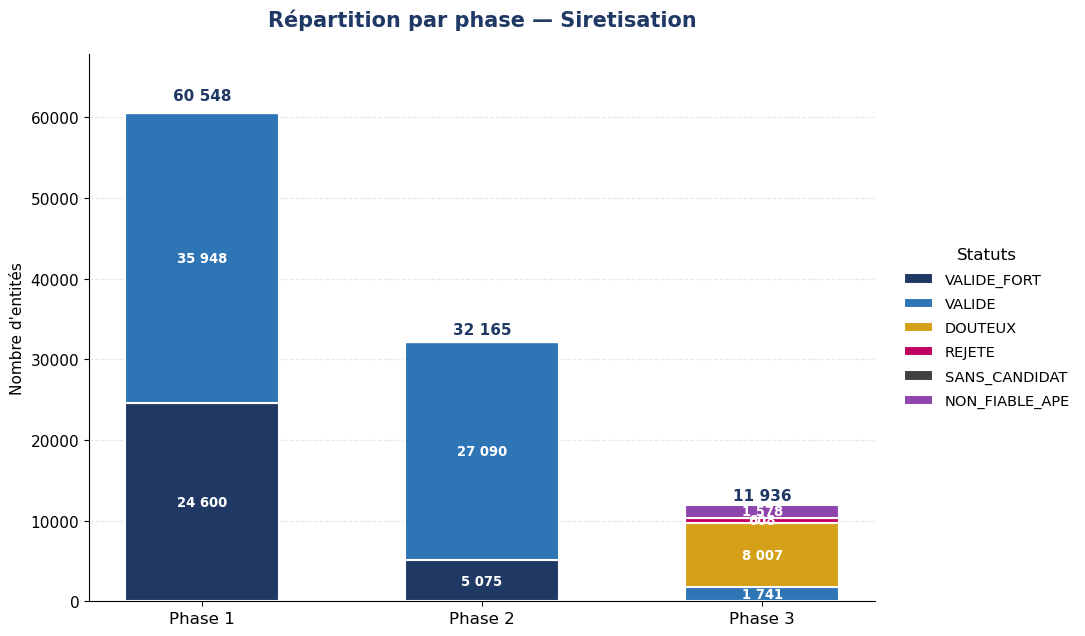

In [9]:
histo_empile_par_phase(
    df_st_synth, ORDRE_STATUTS_ST, COULEURS,
    'Répartition par phase — Siretisation',
    DOSSIER_FIGURES / 'st_par_phase.png',
)

## Construction de la vue de cohérence (SIREN ↔ SIRET)

In [10]:
df_vue = construire_vue_coherence(df_st, df_sn)
print(f'Lignes de la vue : {len(df_vue):,}')
print()
print(df_vue['statut_coherence'].value_counts().to_string())

Lignes de la vue : 102,336

statut_coherence
COHERENT      79474
INCOHERENT    13669
PARTIEL_EJ     7881
PARTIEL_EG     1312


## Synthèse de la cohérence au niveau personne morale

Pour chaque PM traitée, on détermine sa situation finale :
- **PM tous EGE cohérents** : PM validée + tous ses EGE validés avec SIREN cohérent
- **PM avec au moins un EGE incohérent** : PM validée mais ≥ 1 EGE a un SIRET[:9] ≠ SIREN_PM
- **PM seule validée** : PM validée, aucun EGE validé associé
- **EGE seuls validés (sans PM validée)** : situations côté EGE sans PM parente validée

In [11]:
df_avec_match = df_vue[df_vue['statut_coherence'].isin(['COHERENT', 'INCOHERENT'])]
par_pm = df_avec_match.groupby('cle_pm')['statut_coherence'].apply(set)

nb_pm_tous_coh   = sum(1 for s in par_pm if s == {'COHERENT'})
nb_pm_avec_incoh = sum(1 for s in par_pm if 'INCOHERENT' in s)
nb_partiel_pm    = int((df_vue['statut_coherence'] == 'PARTIEL_EJ').sum())
nb_partiel_ege   = int((df_vue['statut_coherence'] == 'PARTIEL_EG').sum())
nb_orphelins     = int((df_vue['statut_coherence'] == 'ORPHELIN').sum())

print('Synthèse au niveau PM :')
print(f'  PM avec tous EGE cohérents      : {nb_pm_tous_coh:,}'.replace(',', ' '))
print(f'  PM avec au moins un incohérent  : {nb_pm_avec_incoh:,}'.replace(',', ' '))
print(f'  PM validées sans EGE validé     : {nb_partiel_pm:,}'.replace(',', ' '))
print(f'  EGE validés sans PM validée     : {(nb_partiel_ege + nb_orphelins):,}'.replace(',', ' '))

Synthèse au niveau PM :
  PM avec tous EGE cohérents      : 39 946
  PM avec au moins un incohérent  : 6 002
  PM validées sans EGE validé     : 7 881
  EGE validés sans PM validée     : 1 312


## Camembert de la cohérence (synthèse au niveau PM)

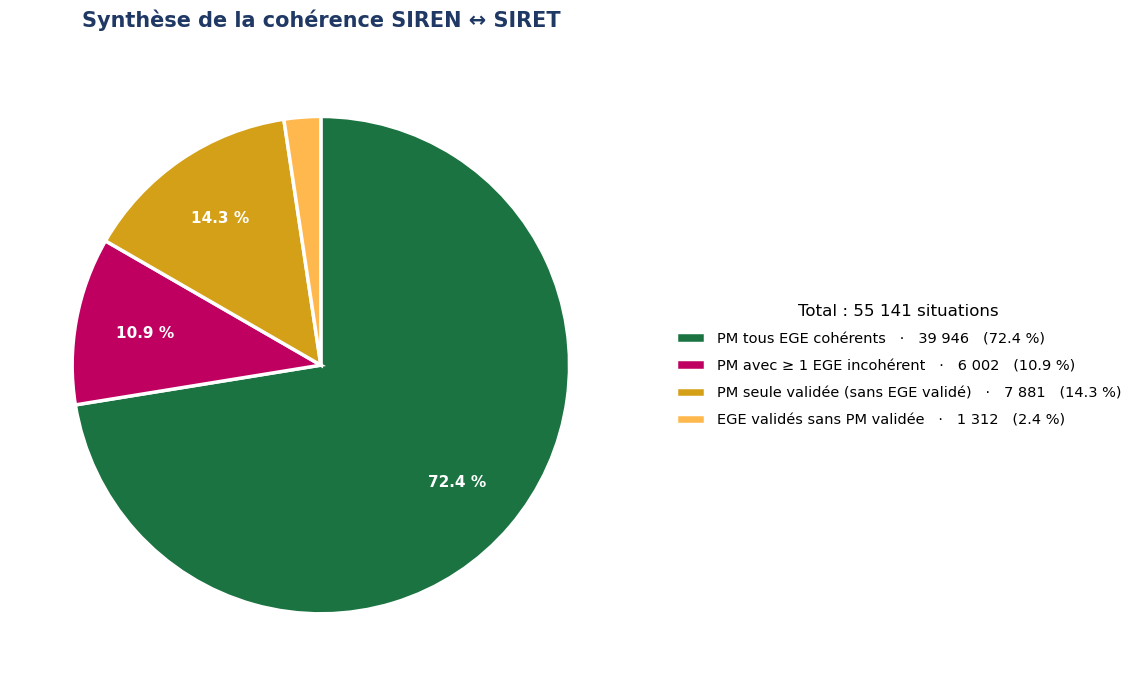

In [12]:
synth_coh = pd.Series({
    'PM tous EGE cohérents':             nb_pm_tous_coh,
    'PM avec ≥ 1 EGE incohérent':        nb_pm_avec_incoh,
    'PM seule validée (sans EGE validé)': nb_partiel_pm,
    'EGE validés sans PM validée':       nb_partiel_ege + nb_orphelins,
})

COULEURS_COHERENCE = {
    'PM tous EGE cohérents':             '#1A7341',
    'PM avec ≥ 1 EGE incohérent':        '#C00060',
    'PM seule validée (sans EGE validé)': '#D4A017',
    'EGE validés sans PM validée':       '#FFB84D',
}

camembert_elegant(
    synth_coh, COULEURS_COHERENCE,
    'Synthèse de la cohérence SIREN ↔ SIRET',
    DOSSIER_FIGURES / 'coherence_pie.png',
    libelle_unite='situations',
)

## Figures produites

```
results/graphiques/
├── sirenisation_pie.png
├── siretisation_pie.png
├── sn_par_phase.png
├── st_par_phase.png
└── coherence_pie.png
```